In [5]:
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
import hdbscan


import matplotlib.pyplot as plt
import umap

import networkx as nx
from matplotlib import cm

import numpy as np

# Pipeline di parsing, embedding e preparazione dei grafi

Il seguente codice implementa una pipeline per l’analisi di sottografi estratti da file testuali strutturati, combinando informazioni strutturali e semantiche dei grafi.

## 1. Parsing dei sottografi da file TXT

La funzione `parse_subgraph(filepath)` legge un file di testo contenente più sottografi e li converte in una lista di grafi diretti NetworkX.

### Formato del file

Il file deve seguire una struttura sequenziale basata su marker:

- `S` → indica l’inizio di un nuovo sottografo  
- `v ID LABEL` → definisce un nodo con identificatore e attributo semantico `label`  
- `d SOURCE TARGET LABEL` oppure `e SOURCE TARGET LABEL` → definisce un arco diretto con etichetta

### Gestione dei riferimenti mancanti

Se un arco fa riferimento a un nodo non ancora definito:

- Il nodo viene creato automaticamente  
- Il nodo riceve la label `"UNK"`

Alla fine della lettura del file, l’ultimo grafo viene salvato se valido.

Output della funzione:
- Lista di grafi diretti (`networkx.DiGraph`).

---

## 2. Sanitizzazione dei grafi

La funzione `sanitize_graph(g)` assicura la consistenza strutturale del grafo prima dell’analisi.

Operazioni eseguite:

- Conversione del grafo in grafo non diretto per stabilizzare le misure topologiche.
- Rimozione dei nodi privi di attributo `label`.

Questa fase riduce il rumore strutturale e previene errori nelle fasi successive di embedding.

---

## 3. Costruzione dei vocabolari semantici

La pipeline costruisce due dizionari fondamentali:

- Vocabulary delle label dei nodi
- Vocabulary delle relazioni tra label dei nodi adiacenti

### Label vocabulary

Ogni label distinta presente nei grafi viene indicizzata.

Mapping generato:

\[
label \rightarrow indice\_vettore
\]

### Edge vocabulary

Le relazioni sono rappresentate come coppie ordinate di label:

\[
(label_{source}, label_{target})
\]

Questo consente di codificare pattern relazionali locali.

---

## 4. Feature semantiche dei grafi

### Feature dei nodi

La funzione `node_semantic_features(g, vocab)` costruisce un vettore one-hot che rappresenta la distribuzione delle label dei nodi nel grafo.

Ogni posizione del vettore indica la presenza di una specifica label.

---

### Feature degli archi

La funzione `edge_semantic_features(g, edge_vocab)` codifica la distribuzione delle coppie di label sugli archi del grafo.

Questo cattura pattern relazionali locali.

---

## 5. Graph embedding strutturale e semantico

La funzione `graph_embedding_features(graphs, label_vocab, edge_vocab)` genera un embedding vettoriale per ogni grafo combinando tre componenti:

### Feature strutturali (6 dimensioni)

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio dei nodi  
- Numero di componenti connesse  
- Lunghezza media dei cammini (se il grafo è connesso)

Se il grafo è vuoto o non valido, viene ignorato.

### Feature semantiche

- Distribuzione delle label dei nodi (one-hot rispetto al vocabulary)
- Distribuzione delle relazioni tra label sugli archi

Output della funzione:

\[
N_{graphs} \times D
\]

dove:

\[
D = 6 + |label\_vocab| + |edge\_vocab|
\]

---

## 6. Pipeline principale

La pipeline esegue le seguenti operazioni:

1. Lettura dei sottografi anomali e corretti da file TXT.
2. Costruzione delle liste di grafi NetworkX.
3. Unione dei dataset grafici.
4. Costruzione dei vocabolari semantici.
5. Calcolo dell’embedding strutturale e semantico.

Output finale:

- `X_embedding`: matrice numerica utilizzabile per clustering o anomaly detection.
- Shape della matrice stampata a video.

---

In [3]:
import networkx as nx
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler

# ==========================================================
# PARSER TXT → LISTA DI GRAFI
# ==========================================================

def parse_subgraph(filepath):
    graphs = []
    G = None

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Inizio nuovo sottografo
            if line == 'S':
                if G is not None and len(G.nodes) > 0:
                    graphs.append(G)
                # Uso Graph() invece di DiGraph() per coerenza con la tua sanitizzazione.
                # Se i tuoi grafi sono orientati, cambia in DiGraph() e rimuovi il sorting nelle feature degli archi.
                G = nx.Graph() 
                continue

            # Nodo
            if line.startswith('v '):
                if G is None: continue
                parts = line.split(maxsplit=2)
                if len(parts) >= 3:
                    node_id, label = parts[1], parts[2]
                    G.add_node(node_id, label=str(label))

            # Arco
            elif line.startswith('d ') or line.startswith('e '):
                if G is None: continue
                parts = line.split(maxsplit=3)
                if len(parts) >= 4:
                    source, target, label = parts[1], parts[2], parts[3]
                    
                    if source not in G.nodes:
                        G.add_node(source, label="UNK")
                    if target not in G.nodes:
                        G.add_node(target, label="UNK")
                        
                    G.add_edge(source, target, label=str(label))

    if G is not None and len(G.nodes) > 0:
        graphs.append(G)

    return graphs

# ==========================================================
# SANITIZATION GRAFI
# ==========================================================

def sanitize_graphs(graphs):
    sanitized = []
    for g in graphs:
        # Trova e rimuovi nodi senza la chiave 'label'
        nodes_to_remove = [n for n, data in g.nodes(data=True) if 'label' not in data]
        g.remove_nodes_from(nodes_to_remove)
        
        # Mantieni il grafo solo se ha ancora nodi
        if len(g.nodes()) > 0:
            sanitized.append(g)
    return sanitized

# ==========================================================
# COSTRUZIONE VOCABOLARI SEMANTICI
# ==========================================================

def build_label_vocabulary(graphs):
    labels = set()
    for g in graphs:
        for _, data in g.nodes(data=True):
            labels.add(data.get("label", "UNK"))
            
    return {l: i for i, l in enumerate(sorted(labels))}

def build_edge_vocabulary(graphs):
    edges = set()
    for g in graphs:
        for u, v, data in g.edges(data=True):
            l1 = g.nodes[u].get("label", "UNK")
            l2 = g.nodes[v].get("label", "UNK")
            edge_label = data.get("label", "UNK")
            
            # Ordino l1 e l2 se il grafo è indiretto, per evitare che (A, edge, B) sia diverso da (B, edge, A)
            l_min, l_max = sorted([l1, l2])
            edges.add((l_min, edge_label, l_max))
            
    return {e: i for i, e in enumerate(sorted(edges))}

# ==========================================================
# FEATURE SEMANTICHE (Ora usano le frequenze!)
# ==========================================================

def node_semantic_features(g, vocab):
    vec = np.zeros(len(vocab))
    for _, data in g.nodes(data=True):
        label = data.get("label", "UNK")
        if label in vocab:
            vec[vocab[label]] += 1  # INCREMENTO il conteggio
    return vec

def edge_semantic_features(g, edge_vocab):
    vec = np.zeros(len(edge_vocab))
    for u, v, data in g.edges(data=True):
        l1 = g.nodes[u].get("label", "UNK")
        l2 = g.nodes[v].get("label", "UNK")
        edge_label = data.get("label", "UNK")
        
        l_min, l_max = sorted([l1, l2])
        triplet = (l_min, edge_label, l_max)
        
        if triplet in edge_vocab:
            vec[edge_vocab[triplet]] += 1 # INCREMENTO il conteggio
    return vec

# ==========================================================
# GRAPH EMBEDDING (STRUTTURA + SEMANTICA)
# ==========================================================

def graph_embedding_features(graphs, label_vocab, edge_vocab):
    embeddings = []

    for g in graphs:
        num_nodes = len(g.nodes())
        num_edges = len(g.edges())
        density = nx.density(g)
        
        degrees = [d for _, d in g.degree()]
        avg_degree = np.mean(degrees) if degrees else 0

        # Gestione sicura per grafi disconnessi
        scc = nx.number_connected_components(g) if not g.is_directed() else nx.number_weakly_connected_components(g)
        
        if num_nodes > 1 and nx.is_connected(g):
            avg_path_length = nx.average_shortest_path_length(g)
        else:
            avg_path_length = 0

        structural_features = np.array([
            num_nodes, num_edges, density, avg_degree, scc, avg_path_length
        ])

        node_features = node_semantic_features(g, label_vocab)
        edge_features = edge_semantic_features(g, edge_vocab)

        graph_vector = np.concatenate([structural_features, node_features, edge_features])
        embeddings.append(graph_vector)

    return np.array(embeddings)


# ==========================================================
# MAIN PIPELINE
# ==========================================================

if __name__ == "__main__":
    # N.B. Sostituisci con i tuoi path reali
    anomalous_path = "../../datasets/custom/anomalous_sub.txt"
    correct_path = "../../datasets/custom/correct_sub.txt"

    # 1. Parsing
    anomalous_graphs = parse_subgraph(anomalous_path)
    correct_graphs = parse_subgraph(correct_path)

    all_graphs = anomalous_graphs + correct_graphs

    # 2. Sanitizzazione IMMEDIATA (fondamentale prima dei vocabolari)
    all_graphs = sanitize_graphs(all_graphs)

    print(f"Totale grafi validi: {len(all_graphs)}")

    # 3. Costruzione vocabolari sulle label reali
    label_vocab = build_label_vocabulary(all_graphs)
    edge_vocab = build_edge_vocabulary(all_graphs)

    print("Dimensione Node Vocab:", len(label_vocab))
    print("Dimensione Edge Vocab (triplette):", len(edge_vocab))

    # 4. Estrazione Embedding
    X_embedding_raw = graph_embedding_features(all_graphs, label_vocab, edge_vocab)
    print("Shape prima dello scaling:", X_embedding_raw.shape)

    # 5. SCALING (Cruciale per K-Means, DBSCAN, ecc.)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_embedding_raw)
    
    # X_embedding_scaled è la matrice finale da passare a Scikit-Learn!

Totale grafi validi: 167
Dimensione Node Vocab: 11
Dimensione Edge Vocab (triplette): 64
Shape prima dello scaling: (167, 81)


# Riduzione dimensionale e clustering degli embedding grafici

Questo blocco di codice implementa una pipeline di analisi non supervisionata su rappresentazioni vettoriali di grafi. L’obiettivo è trasformare gli embedding ad alta dimensionalità in uno spazio latente compatto e strutturare i dati in cluster significativi, mantenendo la relazione topologica tra i pattern osservati.


 *Riduzione dimensionale*

La dimensionalità degli embedding viene ridotta utilizzando UMAP, un algoritmo non lineare che preserva la struttura locale dei dati nello spazio latente. La riduzione dimensionale facilita la visualizzazione, riduce il rumore e rende più efficiente il clustering.

 *Clustering non supervisionato*

I dati proiettati nello spazio ridotto vengono clusterizzati utilizzando HDBSCAN, un algoritmo density-based capace di identificare gruppi di punti ad alta densità e di trattare automaticamente gli outlier come rumore.



In [4]:
X_reduced = umap.UMAP(
    n_neighbors=30,
    n_components=8,
    min_dist=0.05,
    metric='cosine',
    random_state=42
).fit_transform(X_scaled)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=2
)

labels = clusterer.fit_predict(X_reduced)


print("Numero grafi:", X_scaled.shape[0])
print("Dimensione embedding:", X_scaled.shape[1])
print("Noise points:", np.sum(labels == -1))

Numero grafi: 167
Dimensione embedding: 81
Noise points: 40


# Visualizzazione dei cluster tramite UMAP

Questa sezione della pipeline consente di visualizzare i risultati del clustering ottenuto con HDBSCAN riducendo la dimensionalità dello spazio embedding.

Poiché l’embedding dei grafi ha dimensione 6, viene applicata una tecnica di riduzione dimensionale non lineare per rappresentare i dati in 2D.

---

### 1. Riduzione dimensionale con UMAP

Viene utilizzato **Uniform Manifold Approximation and Projection (UMAP)** per proiettare i dati dallo spazio ad alta dimensione allo spazio bidimensionale.

Configurazione utilizzata:

- `n_neighbors = 15`  
  → controlla il livello di preservazione della struttura locale del dataset.

- `min_dist = 0.1`  
  → regola la compattezza dei cluster nella rappresentazione visuale.

- `metric = 'euclidean'`  
  → distanza utilizzata nello spazio embedding normalizzato.

UMAP è particolarmente adatto perché preserva la struttura topologica locale dei dati, rendendo visivamente separabili i cluster trovati.

---

### 2. Visualizzazione dei cluster

I punti proiettati nello spazio 2D sono colorati in base all’etichetta di clustering ottenuta da HDBSCAN.

- Cluster con label ≥ 0 → rappresentano pattern strutturali ricorrenti dei sottografi.
- Label = -1 → rappresentano outlier o comportamenti non densamente supportati (rumore).

Ogni cluster è rappresentato con un marker differente:

- `o` → punti appartenenti a cluster strutturali
- `x` → punti classificati come rumore

---


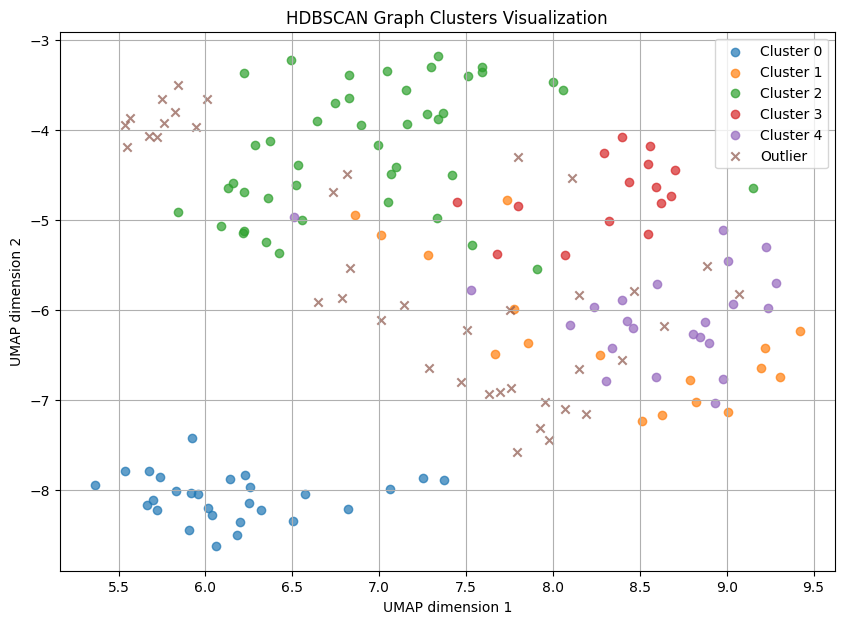

0.4373444616794586


In [5]:
# ===============================
# RIDUZIONE DIMENSIONALE
# ===============================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean'
)

X_2d = reducer.fit_transform(X_scaled)

# ===============================
# PLOT CLUSTER
# ===============================

plt.figure(figsize=(10, 7))

unique_labels = set(labels)

for cluster_id in unique_labels:

    mask = labels == cluster_id

    if cluster_id == -1:
        # outlier
        label_name = "Outlier"
        marker_style = 'x'
    else:
        label_name = f"Cluster {cluster_id}"
        marker_style = 'o'

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=label_name,
        alpha=0.7,
        marker=marker_style
    )

plt.legend()
plt.title("HDBSCAN Graph Clusters Visualization")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.grid(True)

plt.show()

from sklearn.metrics import silhouette_score

mask = labels != -1
print(silhouette_score(X_reduced[mask], labels[mask]))

In [6]:
import pandas as pd

# 1. Ricreiamo le etichette reali (Ground Truth) basate sull'ordine in cui li hai caricati
true_labels = ['Anomalous'] * len(anomalous_graphs) + ['Correct'] * len(correct_graphs)

# 2. Mettiamo tutto in una tabella
df_results = pd.DataFrame({
    'True_Class': true_labels,
    'HDBSCAN_Cluster': labels
})

# 3. Creiamo una matrice di contingenza (Crosstab)
contingency_matrix = pd.crosstab(df_results['True_Class'], df_results['HDBSCAN_Cluster'])
print("--- Analisi dei Cluster vs Ground Truth ---")
print(contingency_matrix)

--- Analisi dei Cluster vs Ground Truth ---
HDBSCAN_Cluster  -1   0   1   2   3   4
True_Class                             
Anomalous         7   7   2   5   3   3
Correct          33  21  15  39  12  20


In [12]:
from sklearn.metrics import f1_score, recall_score, precision_score
import grakel
from sklearn.svm import SVC
import pandas as pd

# 1. Definiamo le griglie dei parametri da esplorare
n_iter_values = [1, 2, 3, 4, 5]
C_values = [0.1, 0.5, 1, 5, 10, 50]

results = []
best_f1 = 0
best_params = {}

print("Inizio l'Hyperparameter Tuning... (potrebbe volerci qualche secondo)\n")

for n_iter in n_iter_values:
    # Calcoliamo il kernel per questo specifico livello di profondità topologica
    wl_kernel = grakel.WeisfeilerLehman(n_iter=n_iter, normalize=True, base_graph_kernel=grakel.VertexHistogram)
    K_train = wl_kernel.fit_transform(G_train)
    K_test = wl_kernel.transform(G_test)
    
    for C in C_values:
        # Addestriamo la SVM per questo specifico valore di C
        svm_model = SVC(kernel='precomputed', C=C, class_weight='balanced', random_state=42)
        svm_model.fit(K_train, y_train)
        
        # Predizione e Valutazione
        y_pred = svm_model.predict(K_test)
        
        # Estraiamo le metriche focalizzandoci SOLO sulle anomalie
        recall = recall_score(y_test, y_pred, pos_label='Anomalous', zero_division=0)
        precision = precision_score(y_test, y_pred, pos_label='Anomalous', zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label='Anomalous', zero_division=0)
        
        results.append({
            'n_iter': n_iter,
            'C': C,
            'Recall': round(recall, 3),
            'Precision': round(precision, 3),
            'F1-Score': round(f1, 3)
        })
        
        # Aggiorniamo il "campione" in carica
        if f1 > best_f1:
            best_f1 = f1
            best_params = {'n_iter': n_iter, 'C': C}

# Trasformiamo i risultati in un DataFrame ordinato per F1-Score decrescente
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("--- Top 5 Configurazioni per le Anomalie ---")
print(df_results.head())

print(f"\nLa configurazione VINCITRICE è: n_iter={best_params.get('n_iter', 'N/A')}, C={best_params.get('C', 'N/A')}")

Inizio l'Hyperparameter Tuning... (potrebbe volerci qualche secondo)

--- Top 5 Configurazioni per le Anomalie ---
   n_iter     C  Recall  Precision  F1-Score
0       1  50.0     0.5      0.364     0.421
1       4   0.5     0.5      0.286     0.364
2       1   5.0     0.5      0.286     0.364
3       1  10.0     0.5      0.286     0.364
4       5   1.0     0.5      0.267     0.348

La configurazione VINCITRICE è: n_iter=1, C=50


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import grakel

# ==========================================================
# 0. RECUPERO MEMORIA E PREPARAZIONE DATI
# ==========================================================
# Ricreiamo X_train e X_test allineandoli perfettamente ai grafi di G_train e G_test
X_train, X_test, _, _ = train_test_split(
    X_scaled, true_labels, test_size=0.3, stratify=true_labels, random_state=42
)

wl_kernel_best = grakel.WeisfeilerLehman(n_iter=1, normalize=True, base_graph_kernel=grakel.VertexHistogram)
K_train_best = wl_kernel_best.fit_transform(G_train)
K_test_best = wl_kernel_best.transform(G_test)

# ==========================================================
# 1. MODELLO STATISTICO (Random Forest sulle feature numeriche)
# ==========================================================
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# predict_proba restituisce le % di confidenza per [Anomalous, Correct]
rf_probs = rf_model.predict_proba(X_test) 

# ==========================================================
# 2. MODELLO TOPOLOGICO (SVM sul WL Kernel)
# ==========================================================
# IMPORTANTE: probability=True ci permette di estrarre le percentuali
svm_model = SVC(kernel='precomputed', C=50, class_weight='balanced', probability=True, random_state=42)
svm_model.fit(K_train_best, y_train)

svm_probs = svm_model.predict_proba(K_test_best)

# ==========================================================
# 3. L'IBRIDO (Sistema a Veto / Logica OR)
# ==========================================================
# Prendiamo le decisioni secche dei due modelli
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(K_test_best)

y_pred_ensemble = []

# Logica OR: se ALMENO UNO dei due dice "Anomalous", scatta l'allarme
for rf_pred, svm_pred in zip(y_pred_rf, y_pred_svm):
    if rf_pred == 'Anomalous' or svm_pred == 'Anomalous':
        y_pred_ensemble.append('Anomalous')
    else:
        y_pred_ensemble.append('Correct')

# ==========================================================
# 4. VALUTAZIONE FINALE
# ==========================================================
print("\n--- Matrice di Confusione (Ensemble a Veto / OR) ---")
conf_matrix = confusion_matrix(y_test, y_pred_ensemble, labels=['Correct', 'Anomalous'])
print(f"Veri Corretti (Top Left): {conf_matrix[0][0]} | Falsi Anomali (Top Right): {conf_matrix[0][1]}")
print(f"Falsi Corretti (Bot Left): {conf_matrix[1][0]} | Vere Anomalie (Bot Right): {conf_matrix[1][1]}")

print("\n--- Report di Classificazione ---")
print(classification_report(y_test, y_pred_ensemble))


--- Matrice di Confusione (Ensemble a Veto / OR) ---
Veri Corretti (Top Left): 36 | Falsi Anomali (Top Right): 7
Falsi Corretti (Bot Left): 4 | Vere Anomalie (Bot Right): 4

--- Report di Classificazione ---
              precision    recall  f1-score   support

   Anomalous       0.36      0.50      0.42         8
     Correct       0.90      0.84      0.87        43

    accuracy                           0.78        51
   macro avg       0.63      0.67      0.64        51
weighted avg       0.82      0.78      0.80        51



Trovati 4 grafi anomali sfuggiti al modello.


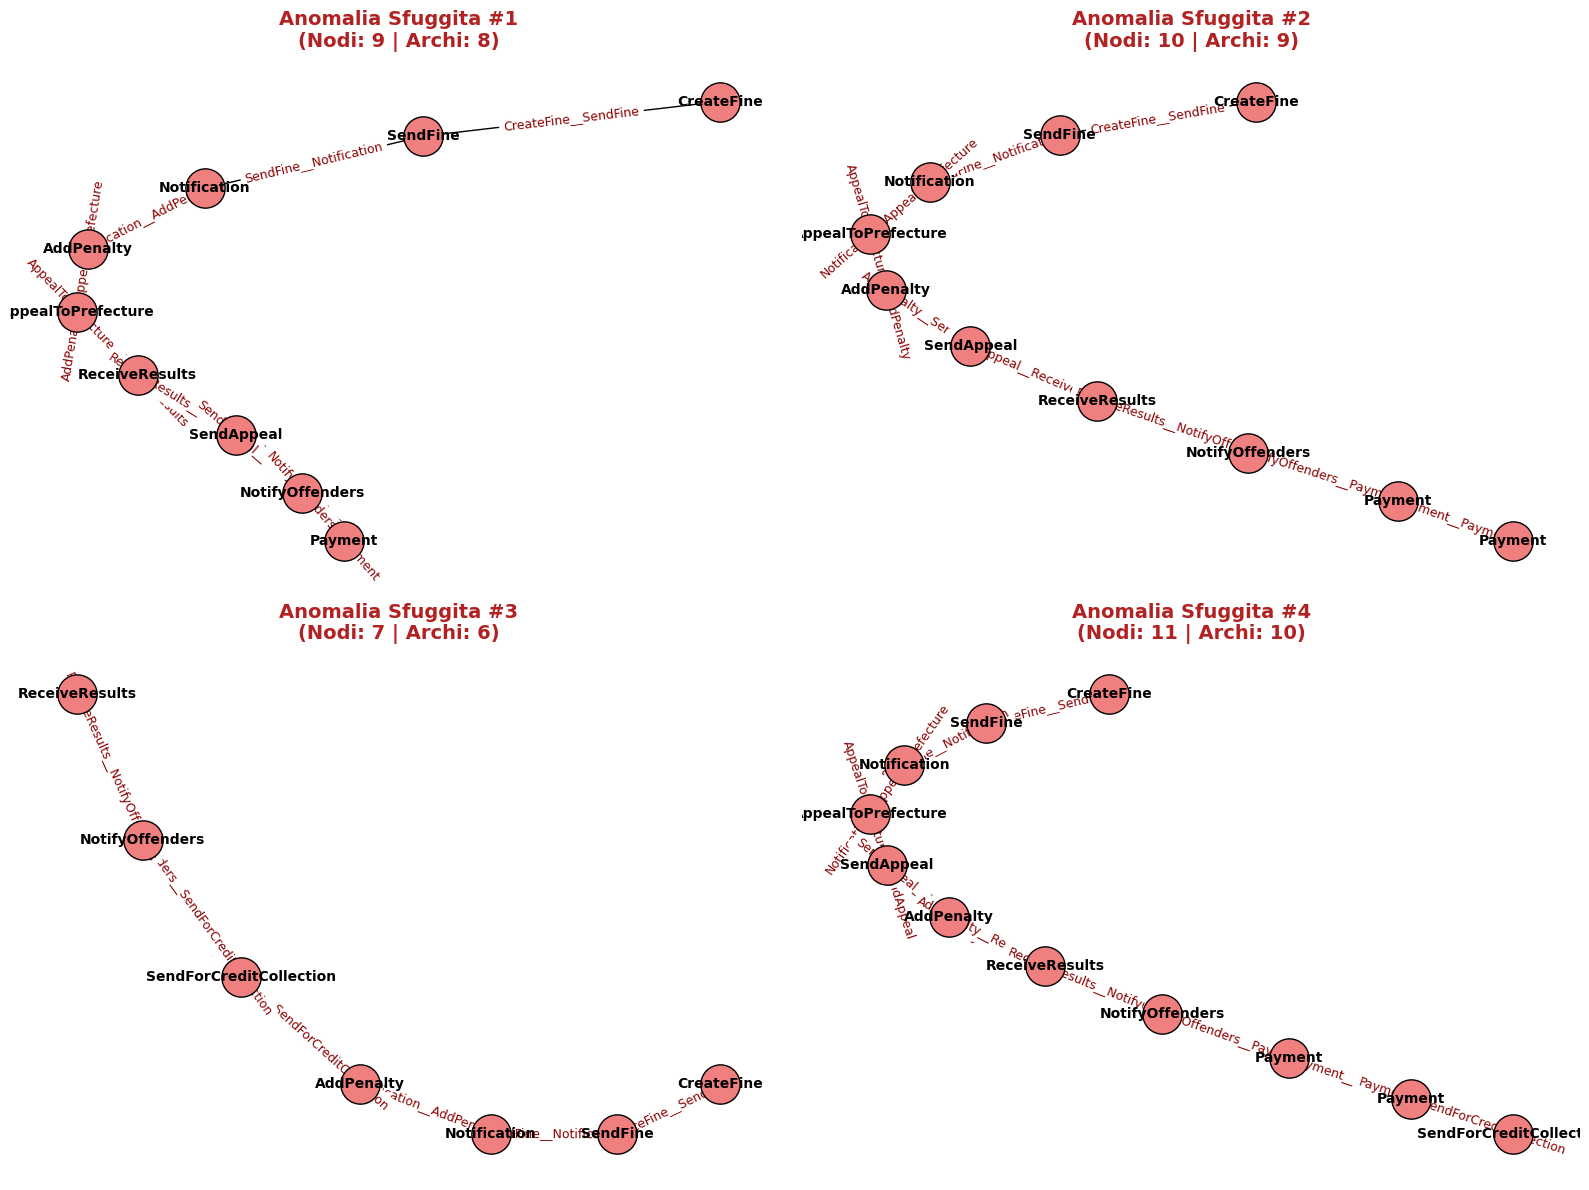

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================================
# 1. RECUPERO GRAFI ORIGINALI
# ==========================================================
# Usiamo lo STESSO random_state=42 per ottenere l'esatto sottoinsieme di test
G_nx_train, G_nx_test, _, _ = train_test_split(
    all_graphs, true_labels, test_size=0.3, stratify=true_labels, random_state=42
)

# ==========================================================
# 2. RICERCA DEI FALSI CORRETTI (Vere anomalie sfuggite)
# ==========================================================
false_negatives_indices = []

for i in range(len(y_test)):
    # Cerchiamo: Classe Reale = Anomalous, Predizione = Correct
    if y_test[i] == 'Anomalous' and y_pred_ensemble[i] == 'Correct':
        false_negatives_indices.append(i)

print(f"Trovati {len(false_negatives_indices)} grafi anomali sfuggiti al modello.")

# ==========================================================
# 3. VISUALIZZAZIONE TOPOLOGICA
# ==========================================================
# Prepariamo una griglia 2x2 per i nostri 4 "ricercati"
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, ax_idx in enumerate(false_negatives_indices):
    if idx >= 4:  # Sicurezza per evitare errori se ce ne fossero di più
        break
        
    g_nx = G_nx_test[ax_idx]
    ax = axes[idx]
    
    # Layout a molla (allontana i nodi per non accavallarli)
    pos = nx.spring_layout(g_nx, seed=42)
    
    # Estraiamo le label semantiche per stamparle
    node_labels = nx.get_node_attributes(g_nx, 'label')
    edge_labels = nx.get_edge_attributes(g_nx, 'label')
    
    # Disegniamo i Nodi
    nx.draw(g_nx, pos, ax=ax, with_labels=True, labels=node_labels, 
            node_color='lightcoral', node_size=800, font_size=10, font_weight='bold', edgecolors='black')
    
    # Disegniamo gli Archi
    nx.draw_networkx_edge_labels(g_nx, pos, edge_labels=edge_labels, ax=ax, font_color='darkred', font_size=9)
    
    ax.set_title(f"Anomalia Sfuggita #{idx+1}\n(Nodi: {len(g_nx.nodes())} | Archi: {len(g_nx.edges())})", 
                 fontsize=14, fontweight='bold', color='firebrick')

plt.tight_layout()
plt.show()

In [40]:
import pandas as pd
n_anomalous = len(anomalous_graphs)

labels_all = labels

df_cluster = pd.DataFrame({
    "cluster": labels_all,
    "type": ["anomalous"] * len(anomalous_graphs) +
            ["correct"] * len(correct_graphs)
})

print(df_cluster.groupby(["cluster", "type"]).size())

cluster  type     
-1       anomalous     4
         correct      13
 0       anomalous     2
         correct       2
 1       correct       7
 2       correct       6
 3       anomalous     1
         correct       3
 4       anomalous     7
         correct      20
 5       anomalous     1
         correct       3
 6       anomalous     1
         correct       4
 7       anomalous     1
         correct       5
 8       anomalous     2
         correct      14
 9       anomalous     1
         correct       3
 10      anomalous     1
         correct      11
 11      anomalous     2
         correct      11
 12      anomalous     1
         correct       5
 13      anomalous     1
         correct       9
 14      anomalous     1
         correct      13
 15      anomalous     1
         correct       6
 16      correct       5
dtype: int64


# Valutazione della purezza dei cluster (Cluster Purity)

Questa sezione misura la qualità del clustering confrontando le etichette ottenute dall’algoritmo non supervisionato con le classi reali disponibili.

Poiché il problema è di tipo anomaly discovery, vengono utilizzate le etichette ground truth:

- `"anomalous"`  
- `"correct"`

---

### 1. Costruzione delle etichette vere

Viene creato il vettore:

\[
y_{true} =
\begin{cases}
anomalous & \text{se il grafo è anomalo} \\
correct & \text{se il grafo è normale}
\end{cases}
\]

Le etichette sono concatenate mantenendo l’ordine dei grafi nella lista embedding.

---

### 2. Struttura del DataFrame di valutazione

Viene costruito un dataframe con due colonne:

- `cluster` → etichetta assegnata da HDBSCAN  
- `true` → classe reale del sottografo

Questo permette di confrontare clustering non supervisionato e ground truth supervisionata.

---

### 3. Calcolo della purity del cluster

La purity misura quanto un cluster contiene elementi della stessa classe.

Per ogni cluster (escludendo il rumore, label = -1):

1. Si seleziona il sottoinsieme dei grafi appartenenti al cluster.
2. Si identifica la classe maggioritaria nel cluster.
3. La purity è calcolata come:

\[
Purity(C) = \frac{\max_{class} |C_{majority}|}{|C|}
\]

Dove:
- \( |C_{majority}| \) è il numero di elementi della classe più frequente nel cluster.
- \( |C| \) è la dimensione totale del cluster.

---

### 4. Interpretazione del risultato

- Purity vicino a 1 → cluster molto omogeneo.
- Purity bassa → cluster misto o poco separabile.

Questa metrica permette di valutare la qualità del raggruppamento dei sottografi rispetto alla verità nota.

---

### 5. Scopo dell’analisi

Questa fase serve a verificare se lo spazio embedding e l’algoritmo di clustering sono adeguati a separare:

- Varianti di processo normali  
- Comportamenti anomali strutturalmente diversi

In [27]:

# costruisci label vere
true_labels = np.array(
    ["anomalous"] * len(anomalous_graphs) +
    ["correct"] * len(correct_graphs)
)

df_eval = pd.DataFrame({
    "cluster": labels,
    "true": true_labels
})

purity_dict = {}

for cluster_id in set(labels):
    if cluster_id == -1:
        continue

    subset = df_eval[df_eval["cluster"] == cluster_id]

    if len(subset) == 0:
        continue

    majority_class = subset["true"].value_counts().max()

    purity_dict[cluster_id] = majority_class / len(subset)

print(purity_dict)

{0: 0.5, 1: 1.0, 2: 1.0, 3: 0.75, 4: 0.7407407407407407, 5: 0.75, 6: 0.8, 7: 0.8333333333333334, 8: 0.875, 9: 0.75, 10: 0.9166666666666666, 11: 0.8461538461538461, 12: 0.8333333333333334, 13: 0.9, 14: 0.9285714285714286, 15: 0.8571428571428571, 16: 1.0}


# Estrazione dei prototipi rappresentativi dei cluster (Medoid Graphs)

Questa funzione consente di identificare il **grafo prototipo** di ogni cluster ottenuto tramite HDBSCAN.

Il prototipo è definito come il **medoid del cluster**, cioè il grafo che minimizza la distanza media rispetto agli altri grafi appartenenti allo stesso cluster nello spazio embedding.

---

### 1. Definizione del prototipo di cluster

Per ogni cluster (escludendo il cluster di rumore etichettato con -1):

1. Vengono individuati gli indici dei grafi appartenenti al cluster.
2. Si estraggono i corrispondenti vettori embedding.
3. Si calcola la matrice di distanza pairwise all’interno del cluster.

La distanza utilizzata è:

\[
D_{ij} = ||x_i - x_j||_2
\]

ottenuta tramite distanza euclidea nello spazio embedding standardizzato.

---

### 2. Selezione del medoid

Il grafo prototipo viene scelto come:

\[
g^* = \arg\min_{g_i \in C} \frac{1}{|C|} \sum_{j \in C} d(g_i, g_j)
\]

dove:

- \( C \) è l’insieme dei grafi del cluster.
- \( d(\cdot,\cdot) \) è la distanza euclidea.
- Il medoid rappresenta il grafo più centrale e stabile del cluster.

---

### 3. Costruzione del dizionario dei prototipi

Il risultato finale è un dizionario:


In [28]:
from sklearn.metrics import pairwise_distances

def extract_cluster_prototypes(graphs, embeddings, labels):

    prototypes = {}

    unique_clusters = set(labels)

    # Converti embeddings in numpy array (solo embedding!)
    embeddings = np.array(embeddings)

    for cluster_id in unique_clusters:

        if cluster_id == -1:
            continue

        cluster_indices = np.where(labels == cluster_id)[0]

        if len(cluster_indices) == 0:
            continue

        cluster_embeddings = embeddings[cluster_indices]

        # distanza pairwise dentro cluster
        dist_matrix = pairwise_distances(cluster_embeddings)

        medoid_local_idx = np.argmin(dist_matrix.mean(axis=1))

        prototype_global_index = cluster_indices[medoid_local_idx]

        prototypes[cluster_id] = graphs[prototype_global_index]

    return prototypes

# ===============================
# Estrai prototipi
# ===============================

all_graphs = anomalous_graphs + correct_graphs

prototypes = extract_cluster_prototypes(
    all_graphs,
    X_scaled,
    labels
)

print("Prototipi estratti per cluster:", prototypes.keys())

Prototipi estratti per cluster: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])


# Calcolo dello score di anomalia dei prototipi di cluster

Questa funzione valuta il livello di anomalia di un grafo prototipo confrontandolo con due riferimenti globali: il comportamento di processo normale e il comportamento anomalo globale.

---

### 1. Rappresentazione embedding dei grafi

Ogni grafo viene trasformato in un vettore numerico tramite una funzione di embedding strutturale.

Le feature del grafo vengono estratte mediante:

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio  
- Numero di componenti connesse  
- Lunghezza media dei cammini

Successivamente, le feature vengono normalizzate utilizzando uno scaler statistico per garantire coerenza nello spazio metrico.

La trasformazione consente di confrontare grafi diversi utilizzando distanza euclidea nello spazio embedding.

---

### 2. Calcolo delle distanze verso i prototipi globali

Per ogni cluster prototype vengono calcolate due distanze principali:

- \( d_{norm} \): distanza dal prototipo del processo normale globale  
- \( d_{anom} \): distanza dal prototipo del comportamento anomalo globale  

Le distanze sono calcolate tramite distanza pairwise nello spazio vettoriale:

\[
d(x,y) = ||x - y||_2
\]

---

### 3. Definizione dello score di anomalia

Lo score di anomalia è definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( \epsilon \) è un termine di stabilizzazione numerica.

---

### 4. Interpretazione dello score

Lo score assume valori nell’intervallo \([0,1]\):

- Score vicino a 0 → il prototype è più simile al comportamento normale.
- Score vicino a 1 → il prototype è più simile al comportamento anomalo.
- Score intorno a 0.5 → zona ambigua o comportamento misto.

---

### 5. Scopo dell’analisi

Questa metrica consente di:

- Valutare la natura strutturale dei cluster di sottografi.
- Supportare decisioni interpretative sulle varianti di processo.
- Distinguere varianti legittime da deviazioni anomale.

In [35]:
def compute_prototype_anomaly_score(
    prototype_graph,
    normal_prototype_graph,
    anomaly_prototype_graph,
    embedding_func,
    scaler
):

    def graph_to_embedding(g):
        feat = embedding_func([g])
        feat_scaled = scaler.transform(feat)
        return feat_scaled[0]

    proto_vec = graph_to_embedding(prototype_graph)
    normal_vec = graph_to_embedding(normal_prototype_graph)
    anomaly_vec = graph_to_embedding(anomaly_prototype_graph)

    d_norm = np.linalg.norm(proto_vec - normal_vec)
    d_anom = np.linalg.norm(proto_vec - anomaly_vec)

    
    score = d_anom / (d_anom + d_norm + 1e-8)

    return score, d_norm, d_anom

# Valutazione di anomalia dei prototipi dei cluster

Questa sezione della pipeline calcola un indice di anomalia per ciascun grafo prototipo dei cluster scoperti tramite HDBSCAN.

L’obiettivo è determinare se il comportamento rappresentato da un cluster è più vicino al processo normativo oppure al comportamento anomalo globale.

---

### 1. Costruzione dei prototipi globali di riferimento

Vengono estratti due prototipi globali utilizzando il criterio del medoid:

- **Prototipo del processo normale globale**, ottenuto dai grafi classificati come `"correct"`.
- **Prototipo del comportamento anomalo globale**, ottenuto dai grafi classificati come `"anomalous"`.

Il prototipo viene selezionato come il grafo che minimizza la distanza media verso gli altri grafi del gruppo nello spazio embedding.

---

### 2. Standardizzazione dello spazio embedding

Prima del confronto, le feature strutturali dei grafi vengono trasformate tramite:

- embedding numerico
- normalizzazione statistica con scaler

Questo garantisce comparabilità metrica tra grafi diversi.

---

### 3. Calcolo dello score di anomalia dei cluster

Per ogni cluster prototype viene calcolato un indice di rischio strutturale definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( d_{norm} \) = distanza dal prototipo del processo normale globale  
- \( d_{anom} \) = distanza dal prototipo del comportamento anomalo globale  
- \( \epsilon \) = termine di stabilizzazione numerica

---

### 4. Output della pipeline

Il risultato finale è un dizionario:


In [36]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# ==========================================================
# Fit scaler sui grafi corretti (best practice)
# ==========================================================

scaler = StandardScaler()

# Embedding dei grafi normali
normal_features = graph_embedding_features(
    correct_graphs,
    label_vocab,
    edge_vocab
)

# Fit solo su normal graphs per evitare leakage
scaler.fit(normal_features)

# ==========================================================
# Prototype extraction
# ==========================================================

normal_global_prototype = extract_cluster_prototypes(
    correct_graphs,
    scaler.transform(normal_features),
    np.zeros(len(correct_graphs))
).get(0)

anomaly_features = graph_embedding_features(
    anomalous_graphs,
    label_vocab,
    edge_vocab
)

anomaly_global_prototype = extract_cluster_prototypes(
    anomalous_graphs,
    scaler.transform(anomaly_features),
    np.zeros(len(anomalous_graphs))
).get(0)


# ==========================================================
# Calcolo scores sui prototypes
# ==========================================================

scores = {}

embedding_wrapper = lambda graphs: graph_embedding_features(
    graphs,
    label_vocab,
    edge_vocab
)

for cluster_id, proto_graph in prototypes.items():

    score, d_norm, d_anom = compute_prototype_anomaly_score(
        proto_graph,
        normal_global_prototype,
        anomaly_global_prototype,
        embedding_wrapper,
        scaler
    )

    scores[cluster_id] = score

print(scores)

{0: 0.5095235241727395, 1: 0.47854844045339323, 2: 0.4869844763787796, 3: 0.5002722186577032, 4: 0.47956591960419476, 5: 0.5197087651756166, 6: 0.48045665997507764, 7: 0.5138597922122633, 8: 0.41955672878772665, 9: 0.5567453343096891, 10: 0.43368860474971593, 11: 0.5046414631826575, 12: 0.47387709027465735, 13: 0.5284248230525985, 14: 0.46993292298952655, 15: 0.564908466271043, 16: 0.4835432828910778}


Notiamo che i prototipi dei cluster 5,6,7 e 8 superano abbondandemente il 0.5, quindi potrebbero essere rappresentativi di comportamenti anomali generalizzati.

# Visualizzazione dei prototipi dei cluster con scala di anomalia

Questa funzione consente di visualizzare i grafo-prototipi dei cluster scoperti nella pipeline di analisi.

L’obiettivo è rappresentare contemporaneamente:

- La struttura topologica del prototipo di ciascun cluster.
- Il livello di anomalia associato al cluster tramite una scala colore continua.

---

### 1. Organizzazione della griglia di visualizzazione

I prototipi vengono disposti in una griglia con un numero fissato di colonne.

Il numero di righe viene calcolato automaticamente:

\[
rows = \lceil \frac{N_{prototypes}}{columns} \rceil
\]

Questo permette di adattare dinamicamente la figura al numero di cluster presenti.

---

### 2. Mappatura dello score di anomalia al colore

La colorazione dei nodi dei grafi prototipo è basata sulla colormap **viridis**, che mappa lo score di anomalia nell’intervallo \([0,1]\).

Lo score è definito come:

\[
Score = \frac{d_{anom}}{d_{anom}+d_{norm}+\epsilon}
\]

dove:

- valori vicini a 0 indicano comportamento più normativo,
- valori vicini a 1 indicano maggiore somiglianza al comportamento anomalo.

---

### 3. Layout grafico dei sottografi

La disposizione dei nodi all’interno di ciascun grafo è ottenuta tramite:

- algoritmo `spring_layout` di NetworkX.

Questo layout simula un sistema fisico di molle, ottimizzando la separazione tra nodi collegati.

---

### 4. Colorbar interpretativa globale

Una barra colore laterale viene aggiunta alla figura per fornire una legenda continua dello score di anomalia.

Configurazione della colorbar:

- Range fissato in \([0,1]\).
- Etichetta esplicativa: **"Anomaly Score"**.

La colorbar è posizionata esternamente alla griglia per evitare sovrapposizioni con i grafi.

---

### 5. Scopo della visualizzazione

Questa rappresentazione supporta:

- Interpretabilità dei cluster di sottografi.
- Analisi qualitativa delle varianti di processo.
- Valutazione visiva del rischio di anomalia strutturale.

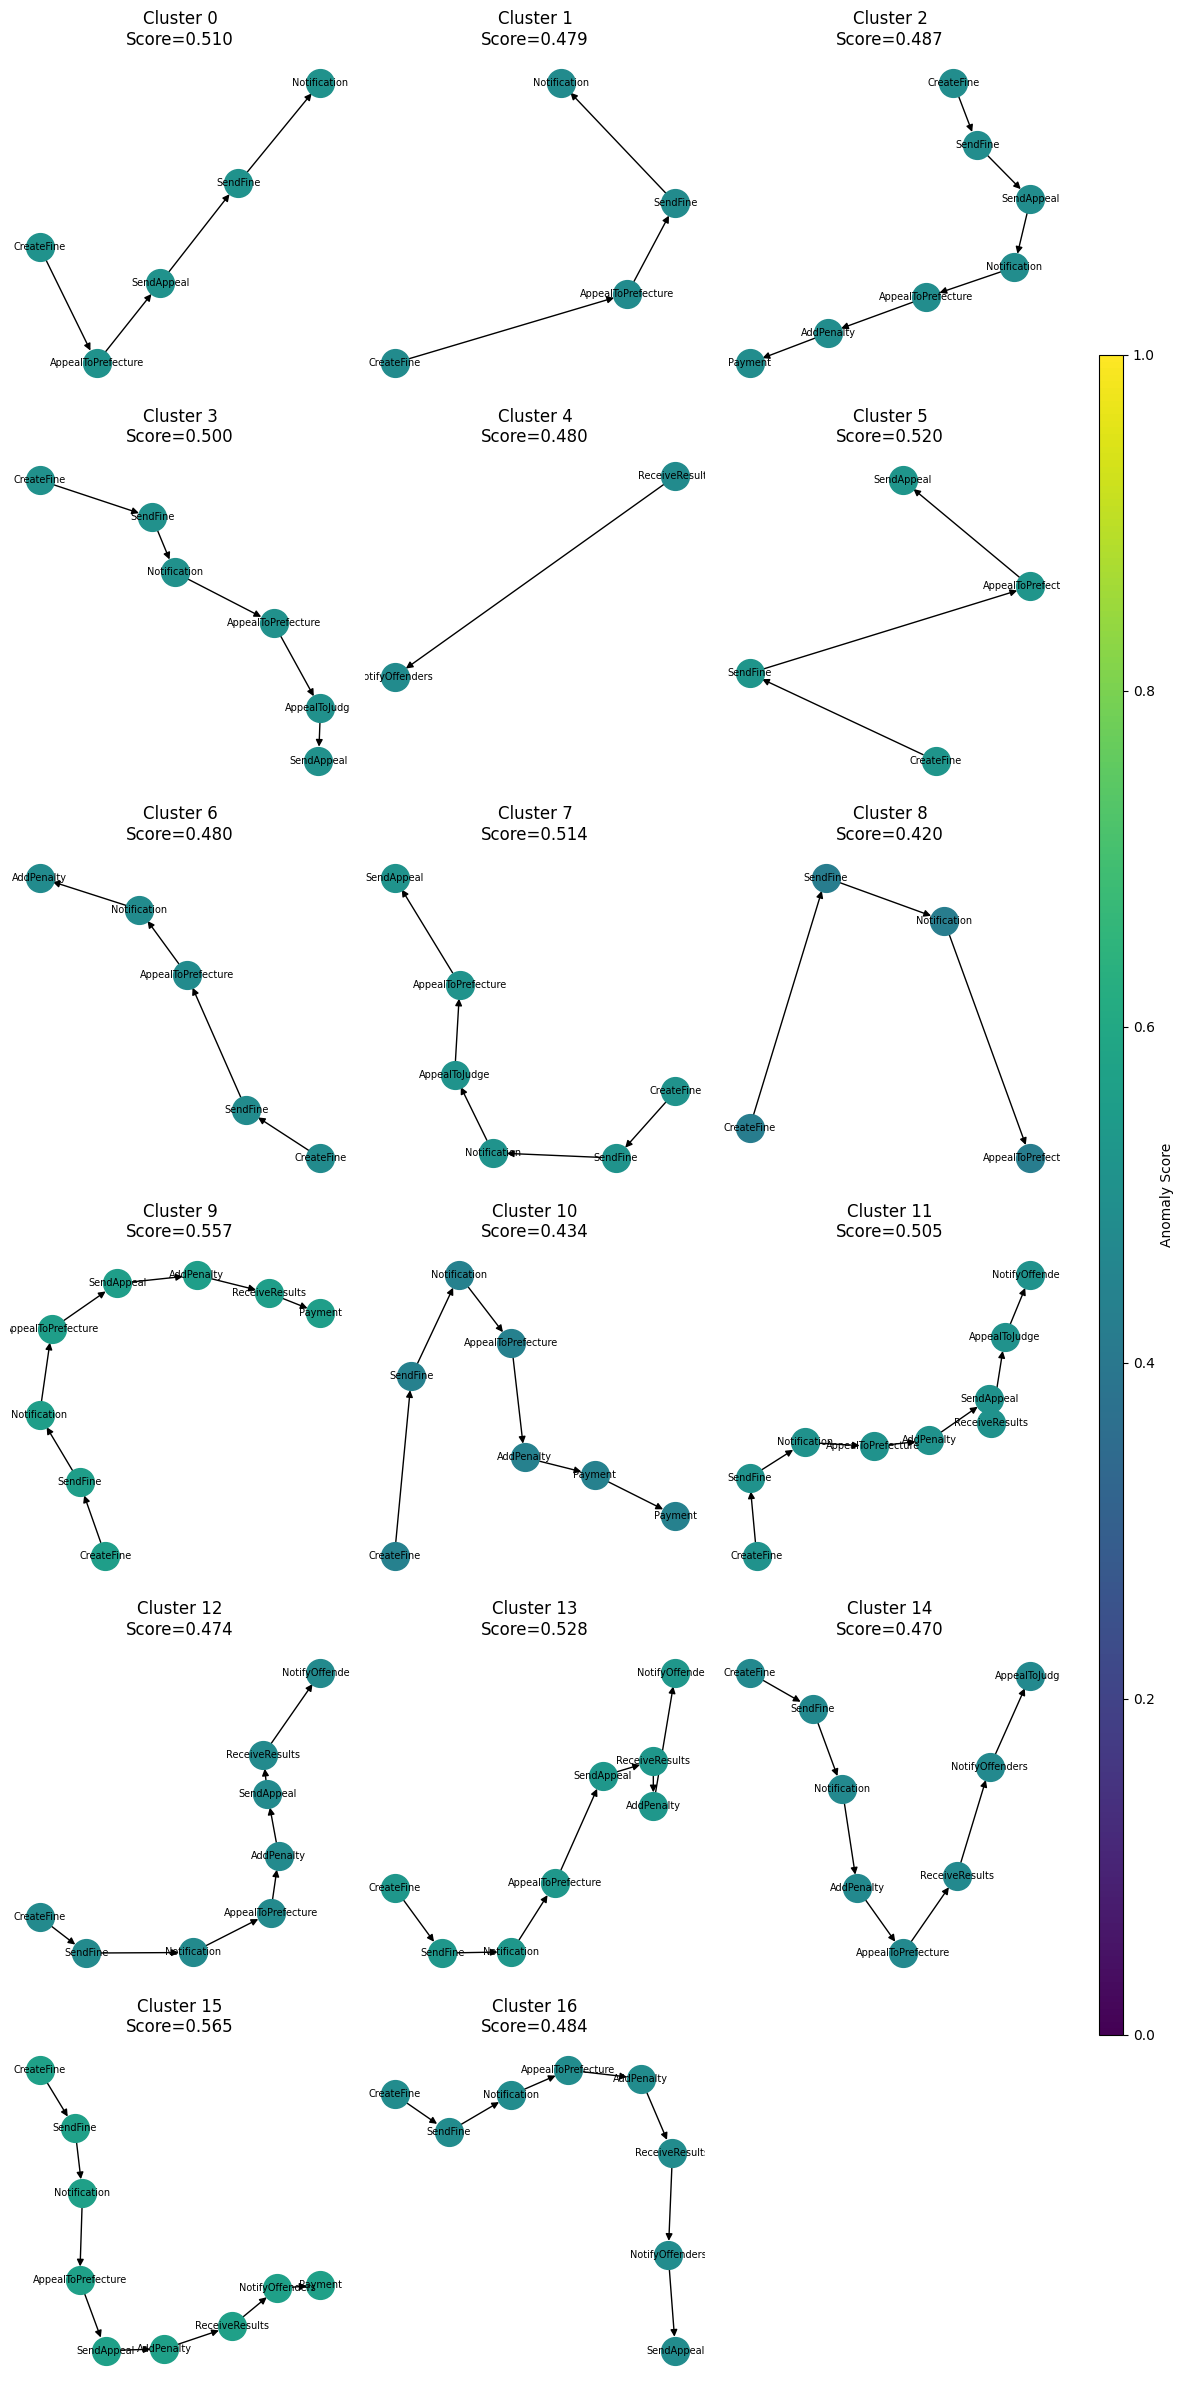

In [37]:

def plot_prototypes_grid(prototypes, scores, cols=3):

    n = len(prototypes)
    rows = int(np.ceil(n / cols))

    colormap = cm.get_cmap("viridis")

    fig = plt.figure(figsize=(4 * cols, 4 * rows))

    # ===============================
    # Plot grafi
    # ===============================

    for idx, (cluster_id, G_proto) in enumerate(prototypes.items()):

        score = scores.get(cluster_id, 0.0)

        color = colormap(score)

        ax = plt.subplot(rows, cols, idx + 1)

        pos = nx.spring_layout(G_proto)

        labels = nx.get_node_attributes(G_proto, 'label')

        nx.draw(
            G_proto,
            pos,
            node_color=[color],
            with_labels=True,
            labels=labels,
            node_size=400,
            font_size=7,
            ax=ax
        )

        plt.title(f"Cluster {cluster_id}\nScore={score:.3f}")

    # ===============================
    # Colorbar laterale globale
    # ===============================
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    sm = plt.cm.ScalarMappable(
        cmap=colormap,
        norm=plt.Normalize(vmin=0, vmax=1)
    )

    sm.set_array([])

    fig.colorbar(sm, cax=cbar_ax, label="Anomaly Score")

    plt.subplots_adjust(right=0.9)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    plt.show()


# ===============================
# Plot grid prototypes
# ===============================

plot_prototypes_grid(prototypes, scores)